# Systematic Trading Case Study

## Cross-Sectional Momentum with Volatility Scaling and Transaction Costs

You are a quantitative researcher at a systematic asset manager.

Your task is to research and backtest a **cross-sectional momentum strategy** on a synthetic universe of liquid futures-like assets.

The notebook intentionally provides:

- realistic but synthetic market data;
- explicit research objectives;
- incomplete code cells for you to fill;
- validation checks;
- progressively harder exercises;
- no final implementation.

The focus is on:

- pandas and NumPy fluency;
- signal construction;
- avoiding look-ahead bias;
- portfolio normalization;
- volatility targeting;
- turnover and transaction costs;
- performance attribution;
- robustness analysis.

## Rules

1. Do not use explicit Python loops unless the exercise permits them.
2. Prefer vectorized pandas/NumPy operations.
3. All positions used for day `t` returns must be based only on information available no later than day `t-1`.
4. Preserve indices and column labels.
5. Read every exercise carefully before coding.


## 0. Setup and synthetic market data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

TRADING_DAYS = 252
rng = np.random.default_rng(42)

dates = pd.bdate_range("2012-01-02", "2025-12-31")

assets = [
    "ES",   # US equities
    "NQ",   # US technology equities
    "DAX",  # European equities
    "NKY",  # Japanese equities
    "TY",   # US 10Y bonds
    "BUND", # German bonds
    "GOLD",
    "OIL",
    "COPPER",
    "EURUSD",
    "JPYUSD",
    "GBPUSD",
]

asset_class = pd.Series({
    "ES": "Equity",
    "NQ": "Equity",
    "DAX": "Equity",
    "NKY": "Equity",
    "TY": "Rates",
    "BUND": "Rates",
    "GOLD": "Commodity",
    "OIL": "Commodity",
    "COPPER": "Commodity",
    "EURUSD": "FX",
    "JPYUSD": "FX",
    "GBPUSD": "FX",
}, name="asset_class")

n_dates = len(dates)
n_assets = len(assets)

# Four latent factors: global risk, rates, commodities, USD.
factor_vols = np.array([0.0080, 0.0045, 0.0090, 0.0055])
factor_corr = np.array([
    [1.00, -0.20,  0.35, -0.15],
    [-0.20, 1.00, -0.10,  0.10],
    [0.35, -0.10, 1.00, -0.05],
    [-0.15, 0.10, -0.05, 1.00],
])
factor_cov = np.outer(factor_vols, factor_vols) * factor_corr

factors = rng.multivariate_normal(
    mean=np.zeros(4),
    cov=factor_cov,
    size=n_dates
)

loadings = pd.DataFrame(
    {
        "global_risk": [1.0, 1.2, 0.9, 0.8, -0.25, -0.20, 0.10, 0.25, 0.45, -0.10, -0.05, -0.08],
        "rates":       [-0.1, -0.1, -0.1, -0.1,  1.10,  1.00, 0.15, -0.10, -0.10, 0.10, 0.20, 0.10],
        "commodity":   [0.1, 0.1, 0.2, 0.2, -0.10, -0.10, 0.80, 1.10, 0.95, 0.00, 0.00, 0.00],
        "usd":         [0.0, 0.0, 0.0, 0.0,  0.00,  0.00, -0.20, -0.20, -0.15, -1.00, 0.75, -0.85],
    },
    index=assets,
)

idio_vol = pd.Series({
    "ES": 0.0060,
    "NQ": 0.0080,
    "DAX": 0.0070,
    "NKY": 0.0075,
    "TY": 0.0030,
    "BUND": 0.0030,
    "GOLD": 0.0060,
    "OIL": 0.0120,
    "COPPER": 0.0090,
    "EURUSD": 0.0045,
    "JPYUSD": 0.0050,
    "GBPUSD": 0.0048,
})

# Persistent trend component so momentum has an economically meaningful signal.
trend = np.zeros((n_dates, n_assets))
trend_shocks = rng.normal(0, 0.00045, size=(n_dates, n_assets))
for t in range(1, n_dates):
    trend[t] = 0.985 * trend[t - 1] + trend_shocks[t]

common_returns = factors @ loadings.to_numpy().T
idio_returns = rng.normal(0, idio_vol.to_numpy(), size=(n_dates, n_assets))

returns = pd.DataFrame(
    common_returns + idio_returns + trend,
    index=dates,
    columns=assets,
)

# Add a few crisis-like shocks.
shock_dates = {
    "2015-08-24": -0.040,
    "2020-03-16": -0.085,
    "2022-06-13": -0.035,
}
for date, shock in shock_dates.items():
    if date in returns.index:
        returns.loc[date, ["ES", "NQ", "DAX", "NKY"]] += shock
        returns.loc[date, ["TY", "BUND", "GOLD"]] -= 0.25 * shock

prices = 100 * np.exp(returns.cumsum())

# Synthetic daily dollar volume used later for liquidity filters and costs.
base_adv = pd.Series({
    "ES": 25e9,
    "NQ": 18e9,
    "DAX": 8e9,
    "NKY": 7e9,
    "TY": 15e9,
    "BUND": 10e9,
    "GOLD": 6e9,
    "OIL": 9e9,
    "COPPER": 3e9,
    "EURUSD": 30e9,
    "JPYUSD": 22e9,
    "GBPUSD": 14e9,
})

volume_noise = rng.lognormal(mean=0.0, sigma=0.35, size=(n_dates, n_assets))
dollar_volume = pd.DataFrame(
    volume_noise * base_adv.to_numpy(),
    index=dates,
    columns=assets,
)

returns.head()

,ES,NQ,DAX,NKY,TY,BUND,GOLD,OIL,COPPER,EURUSD,JPYUSD,GBPUSD
2012-01-02,0.0103,-0.0054,-0.0045,-0.0088,-0.0062,-0.0074,-0.0069,-0.0056,-0.0164,0.0101,0.0013,0.0011
2012-01-03,0.0284,0.0267,0.0261,0.0077,-0.0094,-0.0053,0.0105,0.0151,0.0180,0.0044,-0.0039,0.0099
2012-01-04,-0.0033,0.0052,0.0074,-0.0056,-0.0065,-0.0049,0.0075,0.0015,0.0062,0.0087,-0.0188,0.0042
2012-01-05,-0.0091,0.0052,-0.0002,0.0031,0.0076,0.0048,0.0088,0.0036,0.0130,-0.0024,0.0048,0.0007
2012-01-06,0.0053,-0.0103,0.0022,-0.0003,0.0000,-0.0066,-0.0045,-0.0030,-0.0195,0.0006,-0.0050,0.0067


## 1. Data audit

Before researching a strategy, verify the dataset.

### Tasks

Create the following objects:

- `audit`: a DataFrame indexed by asset containing:
  - start date;
  - end date;
  - number of observations;
  - number of missing observations;
  - annualized mean return;
  - annualized volatility;
  - minimum daily return;
  - maximum daily return.
- `corr`: the full-sample return correlation matrix.

Then identify the three most highly correlated **distinct** asset pairs.

Store them in `top_corr_pairs` as a Series with a two-level index.

### Constraints

- Do not manually enumerate pairs.
- Do not include diagonal correlations.
- Do not include both `(A, B)` and `(B, A)`.


In [2]:
# TODO: build audit, corr, and top_corr_pairs
audit = pd.DataFrame({'start': returns.apply(lambda x: x.first_valid_index())}, index=returns.columns)
audit['end'] = returns.apply(lambda x: x.last_valid_index())
audit['n_obs'] = returns.count(axis=0)
audit['n_missing'] = returns.isna().sum().to_numpy()
audit['ann_mean'] = returns.mean().mul(TRADING_DAYS)
audit['ann_vol'] = returns.std().mul(np.sqrt(TRADING_DAYS))
audit['min_return'] = returns.min()
audit['max_return'] = returns.max()
display(audit.head(5))

corr = returns.corr()
upper_triangle = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool) # k=1 to set the diagonal as NaN, 0 would not mask it but only below
)
display(upper_triangle)
corr_pairs = upper_triangle.stack()
top_corr_pairs = pd.Series(corr_pairs.nlargest(3))
top_corr_pairs


,start,end,n_obs,n_missing,ann_mean,ann_vol,min_return,max_return
ES,2012-01-02,2025-12-31,3653,0,0.1655,0.1733,-0.0934,0.0355
NQ,2012-01-02,2025-12-31,3653,0,-0.0997,0.2072,-0.0780,0.0422
DAX,2012-01-02,2025-12-31,3653,0,-0.1737,0.1781,-0.1093,0.0345
NKY,2012-01-02,2025-12-31,3653,0,0.0370,0.1735,-0.1044,0.0399
TY,2012-01-02,2025-12-31,3653,0,0.0149,0.1158,-0.0252,0.0257


,ES,NQ,DAX,NKY,TY,BUND,GOLD,OIL,COPPER,EURUSD,JPYUSD,GBPUSD
ES,NaN,0.6239,0.5859,0.5434,-0.4051,-0.3543,0.2614,0.2884,0.4277,0.0148,-0.1556,0.0167
NQ,NaN,NaN,0.5807,0.5034,-0.3774,-0.3158,0.2666,0.2781,0.4044,0.0085,-0.1106,0.0214
DAX,NaN,NaN,NaN,0.5179,-0.3766,-0.3056,0.3006,0.3074,0.4319,0.0059,-0.1079,0.0217
NKY,NaN,NaN,NaN,NaN,-0.3495,-0.3224,0.3034,0.3095,0.4033,0.0081,-0.1353,-0.0063
TY,NaN,NaN,NaN,NaN,NaN,0.6596,-0.1564,-0.2386,-0.3214,0.0011,0.2229,0.0196
BUND,NaN,NaN,NaN,NaN,NaN,NaN,-0.1329,-0.1967,-0.2771,0.0171,0.2025,0.0611
GOLD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.4659,0.5045,0.0886,-0.0951,0.0809
OIL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.4905,0.0721,-0.0763,0.0522
COPPER,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0558,-0.1183,0.0499
EURUSD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.3832,0.4668


TY  BUND   0.6596
ES  NQ     0.6239
    DAX    0.5859
dtype: float64

In [3]:
# Validation
assert audit.index.equals(pd.Index(assets))
assert {"start", "end", "n_obs", "n_missing", "ann_mean", "ann_vol", "min_return", "max_return"} <= set(audit.columns)
assert corr.shape == (n_assets, n_assets)
assert len(top_corr_pairs) == 3
assert isinstance(top_corr_pairs.index, pd.MultiIndex)
print("Exercise 1 passed.")

Exercise 1 passed.


## 2. Volatility estimation

Estimate each asset's ex-ante volatility using a 60-day rolling standard deviation.

### Tasks

Create:

- `daily_vol_60`: rolling daily volatility;
- `ann_vol_60`: annualized rolling volatility;
- `inv_vol`: inverse-volatility scores.

### Important

Shift the volatility estimate by one day before it can be used for trading.

At date `t`, your estimate must only depend on returns observed through `t-1`.

Clip annualized volatility to a minimum of 5% to prevent extreme leverage.


In [4]:
# TODO: create daily_vol_60, ann_vol_60, and inv_vol
daily_vol_60 = returns.rolling(60).std().shift(1)
ann_vol_60 = daily_vol_60.mul(np.sqrt(TRADING_DAYS)).clip(lower=0.05)
inv_vol = 1/ann_vol_60


In [5]:
# Validation
assert daily_vol_60.shape == returns.shape
assert ann_vol_60.shape == returns.shape
assert inv_vol.shape == returns.shape
assert ann_vol_60.min().min() >= 0.05
assert ann_vol_60.iloc[:59].isna().all().all()
print("Exercise 2 passed.")

Exercise 2 passed.


## 3. Time-series momentum signal

Construct a classic 12-month momentum signal with a one-month skip.

For each asset and date:

$$
\text{momentum}_t = \frac{P_{t-21}}{P_{t-252}} - 1
$$

### Tasks

Create:

- `mom_12_1`: the raw 12-1 momentum return;
- `ts_signal`: the directional signal equal to `+1`, `0`, or `-1`.

### Important

The signal used on date `t` must be shifted so that today's return does not influence today's position.


In [6]:
# TODO: create mom_12_1 and ts_signal
mom_12_1 = (prices.shift(21)/prices.shift(252) - 1)
display(mom_12_1.tail(5))

conditions = [mom_12_1 > 0, mom_12_1 == 0, mom_12_1 < 0]
values = [1, 0, -1]
signal = np.select(conditions, values, default=np.nan)
ts_signal = pd.DataFrame(signal, index=prices.index, columns=prices.columns).shift(1)
ts_signal

,ES,NQ,DAX,NKY,TY,BUND,GOLD,OIL,COPPER,EURUSD,JPYUSD,GBPUSD
2025-12-25,0.8202,-0.3069,-0.3140,1.4949,-0.2173,-0.4681,0.3702,-0.0607,-0.1911,0.4810,-0.0932,-0.2999
2025-12-26,0.7918,-0.3067,-0.3134,1.5576,-0.2256,-0.4741,0.3629,-0.0557,-0.1848,0.4806,-0.0884,-0.2937
2025-12-29,0.7768,-0.3012,-0.3212,1.5950,-0.2294,-0.4711,0.3314,-0.0759,-0.1959,0.4991,-0.0839,-0.3011
2025-12-30,0.7388,-0.3006,-0.3173,1.5818,-0.2252,-0.4640,0.3138,-0.1000,-0.2262,0.4998,-0.0832,-0.3078
2025-12-31,0.7310,-0.3038,-0.3143,1.6015,-0.2225,-0.4627,0.2915,-0.1132,-0.2183,0.5063,-0.0868,-0.3032


,ES,NQ,DAX,NKY,TY,BUND,GOLD,OIL,COPPER,EURUSD,JPYUSD,GBPUSD
2012-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-25,1.0000,-1.0000,-1.0000,1.0000,-1.0000,-1.0000,1.0000,-1.0000,-1.0000,1.0000,-1.0000,-1.0000
2025-12-26,1.0000,-1.0000,-1.0000,1.0000,-1.0000,-1.0000,1.0000,-1.0000,-1.0000,1.0000,-1.0000,-1.0000
2025-12-29,1.0000,-1.0000,-1.0000,1.0000,-1.0000,-1.0000,1.0000,-1.0000,-1.0000,1.0000,-1.0000,-1.0000
2025-12-30,1.0000,-1.0000,-1.0000,1.0000,-1.0000,-1.0000,1.0000,-1.0000,-1.0000,1.0000,-1.0000,-1.0000


In [7]:
# Validation
assert mom_12_1.shape == prices.shape
assert ts_signal.shape == prices.shape
assert set(np.unique(ts_signal.dropna().to_numpy())) <= {-1.0, 0.0, 1.0}
assert ts_signal.iloc[:253].isna().all().all()
print("Exercise 3 passed.")

Exercise 3 passed.


## 4. Cross-sectional momentum score

Instead of using only the sign of each asset's own trend, rank assets against one another.

### Tasks

For every date:

1. Rank `mom_12_1` cross-sectionally.
2. Convert ranks to percentile ranks.
3. Map percentiles approximately into the interval `[-1, 1]`.
4. Demean the signal cross-sectionally so that the average score is zero.

Store the result in `cs_signal`.

### Interpretation

- Strong relative winners should have positive scores.
- Strong relative losers should have negative scores.
- The portfolio should be approximately dollar-neutral before volatility scaling.


In [8]:
# TODO: create cs_signal
display(mom_12_1.tail(5))
cs_signal = mom_12_1.rank(axis=1)
cs_signal = cs_signal.sub(1).div(cs_signal.count(axis=1) - 1, axis=0) # count and rank use axis differently than operations
cs_signal = cs_signal.mul(2)-1
cs_signal = cs_signal.sub(cs_signal.mean(axis=1), axis=0) # 0 by construction here, but could have a problem if some assets are NaN while others are not + safeguard
display(cs_signal)


,ES,NQ,DAX,NKY,TY,BUND,GOLD,OIL,COPPER,EURUSD,JPYUSD,GBPUSD
2025-12-25,0.8202,-0.3069,-0.3140,1.4949,-0.2173,-0.4681,0.3702,-0.0607,-0.1911,0.4810,-0.0932,-0.2999
2025-12-26,0.7918,-0.3067,-0.3134,1.5576,-0.2256,-0.4741,0.3629,-0.0557,-0.1848,0.4806,-0.0884,-0.2937
2025-12-29,0.7768,-0.3012,-0.3212,1.5950,-0.2294,-0.4711,0.3314,-0.0759,-0.1959,0.4991,-0.0839,-0.3011
2025-12-30,0.7388,-0.3006,-0.3173,1.5818,-0.2252,-0.4640,0.3138,-0.1000,-0.2262,0.4998,-0.0832,-0.3078
2025-12-31,0.7310,-0.3038,-0.3143,1.6015,-0.2225,-0.4627,0.2915,-0.1132,-0.2183,0.5063,-0.0868,-0.3032


,ES,NQ,DAX,NKY,TY,BUND,GOLD,OIL,COPPER,EURUSD,JPYUSD,GBPUSD
2012-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-25,0.8182,-0.6364,-0.8182,1.0000,-0.2727,-1.0000,0.4545,0.2727,-0.0909,0.6364,0.0909,-0.4545
2025-12-26,0.8182,-0.6364,-0.8182,1.0000,-0.2727,-1.0000,0.4545,0.2727,-0.0909,0.6364,0.0909,-0.4545
2025-12-29,0.8182,-0.6364,-0.8182,1.0000,-0.2727,-1.0000,0.4545,0.2727,-0.0909,0.6364,0.0909,-0.4545
2025-12-30,0.8182,-0.4545,-0.8182,1.0000,-0.0909,-1.0000,0.4545,0.0909,-0.2727,0.6364,0.2727,-0.6364


In [9]:
# Validation
assert cs_signal.shape == returns.shape
row_means = cs_signal.mean(axis=1, skipna=True).dropna()
assert np.allclose(row_means, 0.0, atol=1e-12)
assert cs_signal.max().max() <= 1.0 + 1e-12
assert cs_signal.min().min() >= -1.0 - 1e-12
print("Exercise 4 passed.")

Exercise 4 passed.


## 5. Raw portfolio construction

Construct a volatility-scaled cross-sectional momentum portfolio.

### Tasks

1. Multiply `cs_signal` by `inv_vol`.
2. Normalize each row so that gross exposure equals 1:
   $$
   \sum_i |w_{i,t}| = 1
   $$
3. Store the result in `weights_raw`.

### Edge case

Rows where all signals are missing or zero must remain missing or zero, not infinite.


In [10]:
# TODO: create weights_raw
weights_raw = cs_signal * inv_vol
weights_raw = weights_raw.div(weights_raw.abs().sum(axis=1), axis=0)
weights_raw


,ES,NQ,DAX,NKY,TY,BUND,GOLD,OIL,COPPER,EURUSD,JPYUSD,GBPUSD
2012-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-25,0.1137,-0.0719,-0.1143,0.1254,-0.0484,-0.2266,0.0741,0.0250,-0.0093,0.0992,0.0202,-0.0721
2025-12-26,0.1126,-0.0717,-0.1147,0.1249,-0.0482,-0.2261,0.0736,0.0254,-0.0094,0.1010,0.0198,-0.0724
2025-12-29,0.1131,-0.0725,-0.1176,0.1201,-0.0490,-0.2249,0.0726,0.0257,-0.0095,0.1018,0.0200,-0.0733
2025-12-30,0.1106,-0.0507,-0.1143,0.1179,-0.0160,-0.2217,0.0721,0.0084,-0.0281,0.1001,0.0582,-0.1019


In [11]:
# Validation
assert weights_raw.shape == returns.shape
gross = weights_raw.abs().sum(axis=1)
valid = gross[gross > 0]
assert np.allclose(valid, 1.0, atol=1e-10)
assert np.isfinite(weights_raw.fillna(0).to_numpy()).all()
print("Exercise 5 passed.")

Exercise 5 passed.


## 6. Asset-class neutrality

The CIO does not want the strategy's performance to be dominated by persistent exposure to Equity, Rates, Commodity, or FX.

### Tasks

Create `weights_neutral` by:

1. Taking `weights_raw`.
2. Demeaning weights within each asset class on every date.
3. Renormalizing total gross exposure to 1.

### Requirement

For every valid date and each asset class, net exposure should be approximately zero.


In [12]:
# TODO: create weights_neutral
names = list(asset_class.loc[weights_raw.columns])
weights_neutral = weights_raw.copy()
weights_neutral.columns = names

transpose = weights_neutral.T
means = transpose.groupby(transpose.index).transform('mean').T
display(means)
weights_neutral -= means
weights_neutral.columns = weights_raw.columns

weights_neutral = weights_neutral.div(weights_neutral.abs().sum(axis=1), axis=0)
weights_neutral


,Equity,Equity,Equity,Equity,Rates,Rates,Commodity,Commodity,Commodity,FX,FX,FX
2012-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-25,0.0132,0.0132,0.0132,0.0132,-0.1375,-0.1375,0.0299,0.0299,0.0299,0.0158,0.0158,0.0158
2025-12-26,0.0128,0.0128,0.0128,0.0128,-0.1372,-0.1372,0.0299,0.0299,0.0299,0.0161,0.0161,0.0161
2025-12-29,0.0108,0.0108,0.0108,0.0108,-0.1369,-0.1369,0.0296,0.0296,0.0296,0.0162,0.0162,0.0162
2025-12-30,0.0159,0.0159,0.0159,0.0159,-0.1189,-0.1189,0.0175,0.0175,0.0175,0.0188,0.0188,0.0188


,ES,NQ,DAX,NKY,TY,BUND,GOLD,OIL,COPPER,EURUSD,JPYUSD,GBPUSD
2012-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-25,0.1158,-0.0981,-0.1470,0.1293,0.1027,-0.1027,0.0509,-0.0057,-0.0452,0.0962,0.0051,-0.1013
2025-12-26,0.1152,-0.0975,-0.1471,0.1294,0.1027,-0.1027,0.0505,-0.0051,-0.0454,0.0979,0.0043,-0.1022
2025-12-29,0.1184,-0.0964,-0.1486,0.1266,0.1018,-0.1018,0.0498,-0.0045,-0.0453,0.0991,0.0044,-0.1035
2025-12-30,0.0997,-0.0701,-0.1370,0.1074,0.1082,-0.1082,0.0575,-0.0096,-0.0479,0.0856,0.0415,-0.1271


In [13]:
# Validation
assert weights_neutral.shape == returns.shape
for group in asset_class.unique():
    cols = asset_class[asset_class == group].index
    class_net = weights_neutral[cols].sum(axis=1).dropna()
    assert np.allclose(class_net, 0.0, atol=1e-10)

gross = weights_neutral.abs().sum(axis=1)
valid = gross[gross > 0]
assert np.allclose(valid, 1.0, atol=1e-10)
print("Exercise 6 passed.")

Exercise 6 passed.


## 7. Backtest before transaction costs

Compute the portfolio return using lagged weights.

### Tasks

Create:

- `gross_strategy_returns`: daily strategy returns before costs;
- `gross_equity_curve`: cumulative growth of 1 monetary unit.

### Important

The return on date `t` must use positions decided at the end of date `t-1`.


In [14]:
# TODO: create gross_strategy_returns and gross_equity_curve
normal_returns = np.exp(returns) - 1
gross_strategy_returns = (weights_neutral.shift(1) * normal_returns).sum(axis=1, min_count=1)
display(gross_strategy_returns)

gross_equity_curve = (1+gross_strategy_returns).cumprod()
gross_equity_curve


2012-01-02       NaN
2012-01-03       NaN
2012-01-04       NaN
2012-01-05       NaN
2012-01-06       NaN
               ...  
2025-12-25    0.0010
2025-12-26   -0.0019
2025-12-29   -0.0012
2025-12-30    0.0026
2025-12-31   -0.0023
Freq: B, Length: 3653, dtype: float64

2012-01-02      NaN
2012-01-03      NaN
2012-01-04      NaN
2012-01-05      NaN
2012-01-06      NaN
              ...  
2025-12-25   9.0321
2025-12-26   9.0145
2025-12-29   9.0033
2025-12-30   9.0270
2025-12-31   9.0058
Freq: B, Length: 3653, dtype: float64

In [15]:
# Validation
assert isinstance(gross_strategy_returns, pd.Series)
assert gross_strategy_returns.index.equals(returns.index)
assert isinstance(gross_equity_curve, pd.Series)
assert gross_equity_curve.dropna().iloc[0] > 0
print("Exercise 7 passed.")

Exercise 7 passed.


## 8. Turnover and linear transaction costs

Assume one-way trading cost depends on asset class:

| Asset class | Cost |
|---|---:|
| Equity | 1.5 bps |
| Rates | 1.0 bps |
| Commodity | 2.5 bps |
| FX | 0.8 bps |

### Tasks

Create:

- `cost_bps`: Series indexed by asset;
- `daily_turnover_by_asset`: absolute daily change in portfolio weights;
- `daily_turnover`: total daily turnover;
- `transaction_cost`: daily cost in return units;
- `net_strategy_returns`;
- `net_equity_curve`.

Use the convention:

$$
\text{cost}_t = \sum_i |w_{i,t} - w_{i,t-1}| 	\cdot \text{cost rate}_i
$$


In [16]:
# TODO: create the transaction-cost objects
cost_bps_class = pd.Series({'Equity': 1.5, 'Rates': 1.0, 'Commodity': 2.5, 'FX':0.8})
cost_bps = asset_class.reindex(weights_neutral.columns).map(cost_bps_class)
display(cost_bps)

daily_turnover_by_asset = weights_neutral.fillna(0).diff().abs()
daily_turnover = daily_turnover_by_asset.sum(axis=1)
display(daily_turnover.tail(5))

daily_turnover_class = daily_turnover_by_asset.copy()
daily_turnover_class.columns = names
daily_turnover_class = daily_turnover_class.T.groupby(daily_turnover_class.columns).sum().T
daily_turnover_class = daily_turnover_class.reindex(columns=cost_bps_class.index)
display(daily_turnover_class.tail(5))

transaction_cost = daily_turnover_class.mul(cost_bps_class, axis=1).sum(axis=1).div(1e4)
display(transaction_cost.tail(5))

net_strategy_returns = gross_strategy_returns - transaction_cost
display(net_strategy_returns.tail(5))

net_equity_curve = (1+net_strategy_returns).cumprod()
net_equity_curve


ES       1.5000
NQ       1.5000
DAX      1.5000
NKY      1.5000
TY       1.0000
BUND     1.0000
GOLD     2.5000
OIL      2.5000
COPPER   2.5000
EURUSD   0.8000
JPYUSD   0.8000
GBPUSD   0.8000
Name: asset_class, dtype: float64

2025-12-25   0.1590
2025-12-26   0.0062
2025-12-29   0.0146
2025-12-30   0.1781
2025-12-31   0.1218
Freq: B, dtype: float64

,Equity,Rates,Commodity,FX
2025-12-25,0.0687,0.0085,0.0028,0.0791
2025-12-26,0.0014,0.0001,0.0012,0.0035
2025-12-29,0.0086,0.0018,0.0015,0.0027
2025-12-30,0.0756,0.0129,0.0155,0.0741
2025-12-31,0.0531,0.0210,0.0215,0.0262


2025-12-25   0.0000
2025-12-26   0.0000
2025-12-29   0.0000
2025-12-30   0.0000
2025-12-31   0.0000
Freq: B, dtype: float64

2025-12-25    0.0010
2025-12-26   -0.0019
2025-12-29   -0.0012
2025-12-30    0.0026
2025-12-31   -0.0024
Freq: B, dtype: float64

2012-01-02      NaN
2012-01-03      NaN
2012-01-04      NaN
2012-01-05      NaN
2012-01-06      NaN
              ...  
2025-12-25   8.7637
2025-12-26   8.7466
2025-12-29   8.7357
2025-12-30   8.7585
2025-12-31   8.7378
Freq: B, Length: 3653, dtype: float64

In [17]:
# Validation
assert cost_bps.index.equals(pd.Index(assets))
assert (transaction_cost.dropna() >= 0).all()
assert (daily_turnover.dropna() >= 0).all()
common = pd.concat([gross_strategy_returns, net_strategy_returns], axis=1).dropna()
assert (common.iloc[:, 1] <= common.iloc[:, 0] + 1e-14).all()
print("Exercise 8 passed.")

Exercise 8 passed.


## 9. Performance statistics

Write a function:

```python
performance_stats(r, periods_per_year=252)
```

It must return a Series with:

- annualized return;
- annualized volatility;
- Sharpe ratio, assuming zero risk-free rate;
- downside volatility;
- Sortino ratio;
- maximum drawdown;
- Calmar ratio;
- hit rate;
- skewness;
- excess kurtosis;
- worst daily return;
- best daily return.

Then create `stats` comparing gross and net strategy returns.

### Requirements

- Drop missing values inside the function.
- Use geometric annualized return.
- Maximum drawdown must be reported as a negative number.


In [18]:
# TODO: define performance_stats and create stats
def performance_stats(r, periods_per_year=252):
    clean_r = r.dropna(axis=0)

    ann_return = (1+clean_r).cumprod()**(periods_per_year/len(clean_r))-1
    ann_return = ann_return.iloc[-1]
    ann_vol = clean_r.std()*np.sqrt(periods_per_year)
    sharpe = clean_r.mean()*periods_per_year / ann_vol

    neg_r = clean_r.clip(upper=0)
    downside_vol = np.sqrt(np.mean(neg_r ** 2)) * np.sqrt(periods_per_year)
    sortino = clean_r.mean()*periods_per_year / downside_vol

    equity = (1+clean_r).cumprod()
    peak = equity.cummax()
    dd = (equity - peak)/peak
    max_drawdown = dd.min()

    calmar = ann_return / np.abs(max_drawdown)
    hit_rate = (clean_r > 0).mean()
    skew = clean_r.skew()
    excess_kurtosis = clean_r.kurt()

    worst_day = clean_r.min()
    best_day = clean_r.max()
    
    return pd.Series({
        'ann_return': ann_return, 
        'ann_vol': ann_vol, 
        'sharpe': sharpe, 
        'downside_vol': downside_vol, 
        'sortino': sortino,
        'max_drawdown': max_drawdown, 
        'calmar': calmar, 
        'hit_rate': hit_rate, 
        'skew': skew, 
        'excess_kurtosis': excess_kurtosis,
        'worst_day': worst_day, 
        'best_day': best_day
    })

gross_report = performance_stats(gross_strategy_returns)
net_report = performance_stats(net_strategy_returns)
stats = pd.concat([gross_report, net_report], axis=1)
stats.columns = ['Gross', 'Net']
stats

,Gross,Net
ann_return,0.1769,0.1743
ann_vol,0.0399,0.0399
sharpe,4.1079,4.0517
downside_vol,0.0227,0.0228
sortino,7.2159,7.0948
max_drawdown,-0.0703,-0.0720
calmar,2.5162,2.4207
hit_rate,0.5974,0.5956
skew,0.0022,0.0019
excess_kurtosis,0.1215,0.1209


In [19]:
# Validation
required_stats = {
    "ann_return", "ann_vol", "sharpe", "downside_vol", "sortino",
    "max_drawdown", "calmar", "hit_rate", "skew", "excess_kurtosis",
    "worst_day", "best_day"
}
assert required_stats <= set(stats.index)
assert {"Gross", "Net"} <= set(stats.columns)
assert stats.loc["max_drawdown"].max() <= 0
print("Exercise 9 passed.")

Exercise 9 passed.


## 10. Volatility targeting

The portfolio currently has variable realized risk.

Target 10% annualized volatility using a 60-day rolling estimate of the strategy's own volatility.

### Tasks

Create:

- `strategy_ann_vol_60`;
- `leverage`;
- `targeted_returns`;
- `targeted_equity_curve`.

### Constraints

- Shift the volatility estimate by one day.
- Cap leverage at 2.0.
- Do not allow negative leverage.
- Apply leverage to **net** strategy returns.


In [20]:
# TODO: create volatility-targeted strategy objects
strategy_ann_vol_60 = net_strategy_returns.rolling(60).std().mul(np.sqrt(TRADING_DAYS))
display(strategy_ann_vol_60)

target_vol = 0.1
leverage = (target_vol/strategy_ann_vol_60.shift(1)).clip(lower=0, upper=2)
display(leverage)

targeted_returns = leverage.mul(net_strategy_returns)
display(targeted_returns)

targeted_equity_curve = (1+targeted_returns).cumprod()
targeted_equity_curve

2012-01-02      NaN
2012-01-03      NaN
2012-01-04      NaN
2012-01-05      NaN
2012-01-06      NaN
              ...  
2025-12-25   0.0270
2025-12-26   0.0275
2025-12-29   0.0277
2025-12-30   0.0279
2025-12-31   0.0284
Freq: B, Length: 3653, dtype: float64

2012-01-02      NaN
2012-01-03      NaN
2012-01-04      NaN
2012-01-05      NaN
2012-01-06      NaN
              ...  
2025-12-25   2.0000
2025-12-26   2.0000
2025-12-29   2.0000
2025-12-30   2.0000
2025-12-31   2.0000
Freq: B, Length: 3653, dtype: float64

2012-01-02       NaN
2012-01-03       NaN
2012-01-04       NaN
2012-01-05       NaN
2012-01-06       NaN
               ...  
2025-12-25    0.0020
2025-12-26   -0.0039
2025-12-29   -0.0025
2025-12-30    0.0052
2025-12-31   -0.0047
Freq: B, Length: 3653, dtype: float64

2012-01-02       NaN
2012-01-03       NaN
2012-01-04       NaN
2012-01-05       NaN
2012-01-06       NaN
               ...  
2025-12-25   66.6552
2025-12-26   66.3955
2025-12-29   66.2298
2025-12-30   66.5753
2025-12-31   66.2607
Freq: B, Length: 3653, dtype: float64

In [21]:
# Validation
assert leverage.max() <= 2.0 + 1e-12
assert leverage.min() >= 0.0
assert targeted_returns.index.equals(net_strategy_returns.index)
print("Exercise 10 passed.")

Exercise 10 passed.


## 11. Drawdown analysis

Create a function:

```python
drawdown_table(r, top_n=5)
```

It must identify the largest drawdown episodes and return a DataFrame with:

- peak date;
- trough date;
- recovery date;
- drawdown depth;
- peak-to-trough duration in calendar days;
- recovery duration in calendar days.

If a drawdown has not recovered by the end of the sample, set the recovery date to `NaT`.

Apply it to `targeted_returns` and store the result in `dd_table`.


In [22]:
# TODO: define drawdown_table and create dd_table
def drawdown_table(r, top_n=5):
    clean_r = r.dropna(axis=0)
    equity = (1+clean_r).cumprod()
    running_peak = equity.cummax()
    dd = (equity - running_peak)/running_peak

    underwater = dd < 0
    new_episodes = (underwater) & (underwater.shift(1, fill_value=False) == False)
    episode_count = new_episodes.cumsum()
    dd_episodes = pd.DataFrame({'dd': dd, 'count': episode_count})
    dd_episodes = dd_episodes[underwater]

    worst_episodes = dd_episodes.groupby('count')['dd'].min().nsmallest(top_n)
    filtered_df = dd_episodes[dd_episodes['count'].isin(worst_episodes.index)]

    peak_dates = []
    trough_dates = []
    recovery_dates = []
    drawdown_depths = []
    peak_to_trough_durations = []
    recovery_durations = []

    for _, episode in filtered_df.groupby('count'):
        max_dd = episode['dd'].min()
        trough_date = episode['dd'].idxmin()

        start_idx = dd.index.get_loc(episode.index[0])
        if start_idx > 0:
            peak_date = dd.index[start_idx-1]
        else:
            peak_date = dd.index[0]

        end_idx = dd.index.get_loc(episode.index[-1])
        if len(dd) > 1+end_idx:
            recovery_date = dd.index[1+end_idx]
        else:
            recovery_date = pd.NaT

        peak_to_trough_duration = (trough_date - peak_date).days
        if pd.notna(recovery_date):
            recovery_duration = (recovery_date - trough_date).days
        else:
            recovery_duration = np.nan

        peak_dates.append(peak_date)
        trough_dates.append(trough_date)
        recovery_dates.append(recovery_date)
        drawdown_depths.append(max_dd)
        peak_to_trough_durations.append(peak_to_trough_duration)
        recovery_durations.append(recovery_duration)

    df = pd.DataFrame({'peak_date': peak_dates,
        'trough_date': trough_dates,
        'recovery_date': recovery_dates,
        'drawdown': drawdown_depths,
        'peak_to_trough_days': peak_to_trough_durations,
        'recovery_days': recovery_durations
    })

    return df.sort_values('drawdown').reset_index(drop=True)

dd_table = drawdown_table(targeted_returns)
dd_table
    

,peak_date,trough_date,recovery_date,drawdown,peak_to_trough_days,recovery_days
0,2021-12-21,2022-09-07,2022-12-30,-0.1397,260,114
1,2013-03-18,2013-08-26,2013-11-11,-0.1369,161,77
2,2023-05-19,2024-01-05,2024-04-15,-0.1210,231,101
3,2017-11-28,2018-01-30,2018-03-26,-0.1015,63,55
4,2021-08-05,2021-09-29,2021-10-29,-0.0838,55,30


In [23]:
# Validation
assert isinstance(dd_table, pd.DataFrame)
assert len(dd_table) <= 5
assert {"peak_date", "trough_date", "recovery_date", "drawdown",
        "peak_to_trough_days", "recovery_days"} <= set(dd_table.columns)
assert (dd_table["drawdown"] <= 0).all()
print("Exercise 11 passed.")

Exercise 11 passed.


## 12. Signal efficacy: information coefficient

Test whether the signal predicts future returns.

### Tasks

1. Compute next-day returns for each asset.
2. For each date, calculate the cross-sectional Spearman correlation between:
   - today's `cs_signal`;
   - next day's asset returns.
3. Store the daily IC in `daily_ic`.
4. Create `ic_summary` containing:
   - mean IC;
   - standard deviation of IC;
   - annualized IC information ratio;
   - fraction of positive IC observations.

### Important

Do not accidentally correlate the signal with same-day returns.


In [24]:
# TODO: create daily_ic and ic_summary
daily_ic = normal_returns.shift(-1).corrwith(cs_signal, axis=1)
display(daily_ic)

mean_ic = daily_ic.mean()
std_ic = daily_ic.std()
ann_ir = mean_ic/std_ic * np.sqrt(TRADING_DAYS)
pos_ic = (daily_ic > 0).mean()

ic_summary = pd.Series({'mean_ic': mean_ic, 'std_ic': std_ic, 'ic_ir': ann_ir, 'positive_fraction': pos_ic})
ic_summary

2012-01-02       NaN
2012-01-03       NaN
2012-01-04       NaN
2012-01-05       NaN
2012-01-06       NaN
               ...  
2025-12-25   -0.4317
2025-12-26    0.0062
2025-12-29    0.3437
2025-12-30   -0.1891
2025-12-31       NaN
Freq: B, Length: 3653, dtype: float64

mean_ic             0.0635
std_ic              0.3046
ic_ir               3.3087
positive_fraction   0.5390
dtype: float64

In [25]:
# Validation
assert isinstance(daily_ic, pd.Series)
assert {"mean_ic", "std_ic", "ic_ir", "positive_fraction"} <= set(ic_summary.index)
assert 0 <= ic_summary["positive_fraction"] <= 1
print("Exercise 12 passed.")

Exercise 12 passed.


## 13. Quantile portfolio test

Perform a cross-sectional signal-sorting test.

### Tasks

On every date:

1. Rank assets by `cs_signal`.
2. Assign them to four quantiles.
3. Compute next-day equal-weight return for each quantile.
4. Store returns in `quantile_returns` with columns `Q1`, `Q2`, `Q3`, `Q4`.
5. Create the long-short spread `Q4_minus_Q1`.

### Notes

- Handle dates with insufficient valid assets.
- The signal must precede the return.
- This is a research diagnostic, separate from the production portfolio.


In [26]:
# TODO: create quantile_returns and Q4_minus_Q1
ranked_signal = cs_signal.apply(lambda x: pd.qcut(x, 4, labels=False, duplicates='drop'), axis=1)
display(ranked_signal)
ranked_signal_long = ranked_signal.stack()
returns_long = normal_returns.shift(-1).stack()

long_df = pd.concat([ranked_signal_long.rename('quantile'),returns_long.rename('next_return'),],axis=1,).dropna()
display(long_df)

ew_returns = long_df.groupby([long_df.index.get_level_values(0), 'quantile'])['next_return'].agg('mean')
display(ew_returns)

quantile_returns = ew_returns.unstack('quantile')
quantile_returns = quantile_returns.rename(columns={0: 'Q1',1: 'Q2',2: 'Q3',3: 'Q4'})
display(quantile_returns)

Q4_minus_Q1 = quantile_returns['Q4'] - quantile_returns['Q1']
Q4_minus_Q1

,ES,NQ,DAX,NKY,TY,BUND,GOLD,OIL,COPPER,EURUSD,JPYUSD,GBPUSD
2012-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-25,3.0000,0.0000,0.0000,3.0000,1.0000,0.0000,2.0000,2.0000,1.0000,3.0000,2.0000,1.0000
2025-12-26,3.0000,0.0000,0.0000,3.0000,1.0000,0.0000,2.0000,2.0000,1.0000,3.0000,2.0000,1.0000
2025-12-29,3.0000,0.0000,0.0000,3.0000,1.0000,0.0000,2.0000,2.0000,1.0000,3.0000,2.0000,1.0000
2025-12-30,3.0000,1.0000,0.0000,3.0000,1.0000,0.0000,2.0000,2.0000,1.0000,3.0000,2.0000,0.0000


quantile  next_return
2012-12-19 ES        1.0000       0.0089
           NQ        2.0000       0.0162
           DAX       1.0000       0.0100
           NKY       1.0000       0.0195
           TY        2.0000       0.0050
...                     ...          ...
2025-12-30 OIL       2.0000       0.0090
           COPPER    1.0000       0.0058
           EURUSD    3.0000       0.0046
           JPYUSD    2.0000      -0.0042
           GBPUSD    0.0000       0.0078

[40800 rows x 2 columns]

            quantile
2012-12-19  0.0000      0.0055
            1.0000      0.0128
            2.0000      0.0105
            3.0000      0.0035
2012-12-20  0.0000     -0.0004
                         ...  
2025-12-29  3.0000      0.0020
2025-12-30  0.0000      0.0026
            1.0000     -0.0025
            2.0000     -0.0003
            3.0000     -0.0005
Name: next_return, Length: 13600, dtype: float64

quantile,Q1,Q2,Q3,Q4
2012-12-19,0.0055,0.0128,0.0105,0.0035
2012-12-20,-0.0004,-0.0021,0.0006,0.0048
2012-12-21,0.0031,-0.0061,0.0019,0.0018
2012-12-24,0.0038,0.0184,0.0137,0.0051
2012-12-25,-0.0003,-0.0037,0.0037,0.0065
...,...,...,...,...
2025-12-24,0.0019,-0.0018,-0.0031,0.0058
2025-12-25,-0.0047,-0.0015,-0.0082,-0.0087
2025-12-26,-0.0004,-0.0026,-0.0010,0.0002
2025-12-29,-0.0075,-0.0065,-0.0112,0.0020


2012-12-19   -0.0021
2012-12-20    0.0052
2012-12-21   -0.0013
2012-12-24    0.0013
2012-12-25    0.0068
               ...  
2025-12-24    0.0039
2025-12-25   -0.0040
2025-12-26    0.0006
2025-12-29    0.0095
2025-12-30   -0.0031
Length: 3400, dtype: float64

In [27]:
# Validation
assert list(quantile_returns.columns) == ["Q1", "Q2", "Q3", "Q4"]
assert isinstance(Q4_minus_Q1, pd.Series)
assert Q4_minus_Q1.index.equals(quantile_returns.index)
print("Exercise 13 passed.")

Exercise 13 passed.


## 14. Regime analysis

Define two market regimes using the 60-day realized volatility of the equally weighted equity basket:

- `High vol`: above its expanding historical median;
- `Low vol`: at or below its expanding historical median.

### Tasks

Create:

- `equity_basket_return`;
- `equity_realized_vol`;
- `regime`;
- `regime_stats`, containing annualized return, volatility, Sharpe ratio, and observation count for `targeted_returns` in each regime.

### Constraint

The regime classification used on date `t` must not use information from date `t`.


In [28]:
# TODO: create regime variables and regime_stats
returns_class = returns.copy()
returns_class.columns = list(asset_class.loc[returns.columns])
to_keep = returns_class.columns == 'Equity'
equity_basket_return = returns_class.loc[:, to_keep].mean(axis=1).dropna()
display(equity_basket_return)

equity_realized_vol = equity_basket_return.rolling(60).std().mul(np.sqrt(TRADING_DAYS)).shift(1).dropna()
display(equity_realized_vol)

expanding_median = equity_realized_vol.expanding().median()
regime = pd.Series(np.where(equity_realized_vol > expanding_median, 'High vol', 'Low vol'), index=equity_realized_vol.index)
display(regime)

regime_stats = pd.concat([targeted_returns.rename('ret'), regime.rename('regime')], axis=1)
regime_stats = (
    regime_stats
    .groupby('regime')
    .agg(
        ann_return=(
            'ret', lambda x: (1+x.dropna()).prod()**(TRADING_DAYS/x.dropna().shape[0])-1
        ),
        ann_vol=(
            'ret', lambda x: x.dropna().std()*np.sqrt(TRADING_DAYS)
        ),
        sharpe=(
            'ret', lambda x: x.dropna().mean()/x.dropna().std()*np.sqrt(TRADING_DAYS)
        ),
        n_obs=(
            'ret', lambda x: x.notna().sum()
        ),
    )
)        
regime_stats

2012-01-02   -0.0021
2012-01-03    0.0222
2012-01-04    0.0009
2012-01-05   -0.0002
2012-01-06   -0.0008
               ...  
2025-12-25    0.0031
2025-12-26   -0.0124
2025-12-29   -0.0018
2025-12-30   -0.0050
2025-12-31   -0.0038
Freq: B, Length: 3653, dtype: float64

2012-03-26   0.1464
2012-03-27   0.1473
2012-03-28   0.1444
2012-03-29   0.1509
2012-03-30   0.1524
              ...  
2025-12-25   0.1291
2025-12-26   0.1292
2025-12-29   0.1304
2025-12-30   0.1305
2025-12-31   0.1300
Freq: B, Length: 3593, dtype: float64

2012-03-26     Low vol
2012-03-27    High vol
2012-03-28     Low vol
2012-03-29    High vol
2012-03-30    High vol
                ...   
2025-12-25     Low vol
2025-12-26     Low vol
2025-12-29     Low vol
2025-12-30     Low vol
2025-12-31     Low vol
Freq: B, Length: 3593, dtype: str

,ann_return,ann_vol,sharpe,n_obs
regime,,,,
High vol,0.3652,0.0821,3.8361,1666
Low vol,0.3792,0.0771,4.2127,1674


In [29]:
# Validation
assert set(regime.dropna().unique()) <= {"High vol", "Low vol"}
assert {"ann_return", "ann_vol", "sharpe", "n_obs"} <= set(regime_stats.columns)
print("Exercise 14 passed.")

Exercise 14 passed.


## 15. Parameter robustness

Evaluate momentum lookback horizons of:

- 63 days;
- 126 days;
- 252 days.

Use a fixed 21-day skip for every horizon.

For each lookback:

1. construct a cross-sectional momentum score;
2. volatility-scale it using `inv_vol`;
3. impose asset-class neutrality;
4. normalize gross exposure to 1;
5. lag positions by one day;
6. subtract the same transaction-cost model;
7. compute annualized return, volatility, Sharpe ratio, maximum drawdown, and average daily turnover.

Store the results in `robustness`.

### This exercise may use a loop

The main objective is to keep the implementation readable and avoid duplicated logic.


In [30]:
# TODO: create robustness
def robustness_check(lookback, prices):
    mom = (prices.shift(21)/prices.shift(lookback) - 1)

    cs_signal = mom.rank(axis=1).sub(1)
    cs_signal = cs_signal.div(cs_signal.count(axis=1) - 1, axis=0).mul(2)-1
    cs_signal = cs_signal.sub(cs_signal.mean(axis=1), axis=0)

    normal_returns = prices.pct_change()
    returns = np.log1p(normal_returns)

    inv_vol = 1/returns.rolling(60).std().shift(1).mul(np.sqrt(TRADING_DAYS)).clip(lower=0.05)
    weights_raw = (cs_signal*inv_vol)
    weights_raw = weights_raw.div(weights_raw.abs().sum(axis=1), axis=0)

    weights_neutral = weights_raw.copy()
    weights_neutral.columns = names
    transpose = weights_neutral.T
    means = transpose.groupby(transpose.index).transform('mean').T
    weights_neutral -= means
    weights_neutral.columns = weights_raw.columns
    weights_neutral = weights_neutral.div(weights_neutral.abs().sum(axis=1), axis=0)

    daily_turnover_by_asset = weights_neutral.fillna(0).diff().abs()
    daily_turnover = daily_turnover_by_asset.sum(axis=1)
    daily_turnover_class = daily_turnover_by_asset.copy()
    daily_turnover_class.columns = names
    daily_turnover_class = daily_turnover_class.T.groupby(daily_turnover_class.columns).sum().T.reindex(columns=cost_bps_class.index)
    transaction_cost = daily_turnover_class.mul(cost_bps_class, axis=1).sum(axis=1).div(1e4)

    gross_strategy_returns = (weights_neutral.shift(1) * normal_returns).sum(axis=1, min_count=1)
    net_strategy_returns = gross_strategy_returns - transaction_cost

    stats = performance_stats(net_strategy_returns)
    ann_ret = stats['ann_return']
    ann_vol = stats['ann_vol']
    sharpe = stats['sharpe']
    max_dd = stats['max_drawdown']
    avg_turnover = daily_turnover.mean()

    s = pd.Series({'ann_return': ann_ret, 'ann_vol': ann_vol, 'sharpe': sharpe, 'max_drawdown': max_dd, 'avg_daily_turnover': avg_turnover})

    return s, net_strategy_returns

dic = {}

for i in [63, 126, 252]:
    dic[i], _ = robustness_check(i, prices)

robustness = pd.DataFrame(dic).T
robustness
    

,ann_return,ann_vol,sharpe,max_drawdown,avg_daily_turnover
63,0.3588,0.0399,7.7047,-0.0374,0.1684
126,0.2653,0.0386,6.1145,-0.0620,0.0980
252,0.1743,0.0399,4.0517,-0.0720,0.0598


In [31]:
# Validation
assert robustness.index.equals(pd.Index([63, 126, 252], name="lookback"))
assert {"ann_return", "ann_vol", "sharpe", "max_drawdown", "avg_daily_turnover"} <= set(robustness.columns)
print("Exercise 15 passed.")

Exercise 15 passed.


## 16. Walk-forward evaluation

Split the backtest into:

- training period: 2012–2018;
- validation period: 2019–2021;
- test period: 2022–2025.

### Tasks

Using the `robustness` logic:

1. Select the lookback with the highest Sharpe ratio during the training period.
2. Report its validation-period statistics.
3. Do not change the parameter after observing validation results.
4. Report final test-period statistics.
5. Store the selected parameter in `selected_lookback`.
6. Store results in `walk_forward_summary`.

### Objective

Demonstrate the distinction between:

- in-sample parameter selection;
- validation;
- untouched out-of-sample testing.


In [32]:
# TODO: perform the walk-forward analysis
training = prices.loc['2012':'2018']

for i in [63, 126, 252]:
    dic[i], _ = robustness_check(i, training)

training_robustness = pd.DataFrame(dic).T
display(training_robustness)
best = training_robustness['sharpe'].idxmax()
print(f'best lookback: {best} days')

returns_total = robustness_check(best, prices)[1]

training_net_returns = returns_total.loc['2012':'2018']
training_report = performance_stats(training_net_returns)
display(training_report)

validation_net_returns = returns_total.loc['2019':'2021']
validation_report = performance_stats(validation_net_returns)
display(validation_report)

test_net_returns = returns_total.loc['2022':'2025']
test_report = performance_stats(test_net_returns)
display(test_report)

selected_lookback = best

walk_forward_summary = pd.DataFrame([training_report, validation_report, test_report], index=['Train', 'Validation', 'Test'])
walk_forward_summary


,ann_return,ann_vol,sharpe,max_drawdown,avg_daily_turnover
63,0.3067,0.0398,6.7518,-0.0374,0.1739
126,0.2359,0.0387,5.4891,-0.0620,0.1012
252,0.2095,0.0404,4.7326,-0.0707,0.0560


best lookback: 63 days


ann_return         0.3067
ann_vol            0.0398
sharpe             6.7518
downside_vol       0.0195
sortino           13.7705
max_drawdown      -0.0374
calmar             8.2083
hit_rate           0.6623
skew               0.0332
excess_kurtosis    0.4371
worst_day         -0.0092
best_day           0.0110
dtype: float64

ann_return         0.4655
ann_vol            0.0421
sharpe             9.1112
downside_vol       0.0181
sortino           21.2105
max_drawdown      -0.0207
calmar            22.5144
hit_rate           0.7245
skew              -0.0081
excess_kurtosis   -0.0392
worst_day         -0.0067
best_day           0.0092
dtype: float64

ann_return         0.3713
ann_vol            0.0382
sharpe             8.2948
downside_vol       0.0172
sortino           18.3663
max_drawdown      -0.0276
calmar            13.4421
hit_rate           0.6999
skew              -0.0196
excess_kurtosis    0.2120
worst_day         -0.0075
best_day           0.0107
dtype: float64

,ann_return,ann_vol,sharpe,downside_vol,sortino,max_drawdown,calmar,hit_rate,skew,excess_kurtosis,worst_day,best_day
Train,0.3067,0.0398,6.7518,0.0195,13.7705,-0.0374,8.2083,0.6623,0.0332,0.4371,-0.0092,0.0110
Validation,0.4655,0.0421,9.1112,0.0181,21.2105,-0.0207,22.5144,0.7245,-0.0081,-0.0392,-0.0067,0.0092
Test,0.3713,0.0382,8.2948,0.0172,18.3663,-0.0276,13.4421,0.6999,-0.0196,0.2120,-0.0075,0.0107


In [33]:
# Validation
assert selected_lookback in {63, 126, 252}
assert {"Train", "Validation", "Test"} <= set(walk_forward_summary.index)
assert {"ann_return", "ann_vol", "sharpe", "max_drawdown"} <= set(walk_forward_summary.columns)
print("Exercise 16 passed.")

Exercise 16 passed.


## 17. Visualization

Produce three separate figures:

1. Gross, net, and volatility-targeted equity curves.
2. Underwater drawdown chart for the targeted strategy.
3. Rolling 252-day Sharpe ratio of the targeted strategy.

### Requirements

- Use clear titles and axis labels.
- Include legends where useful.
- Do not use subplots.
- Do not hard-code the plotted results.


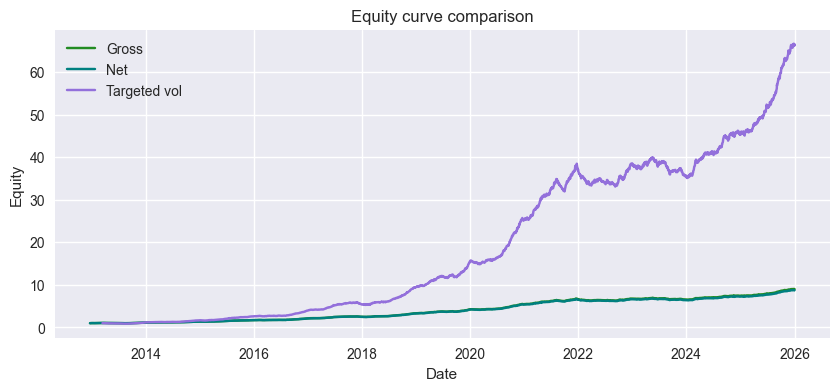

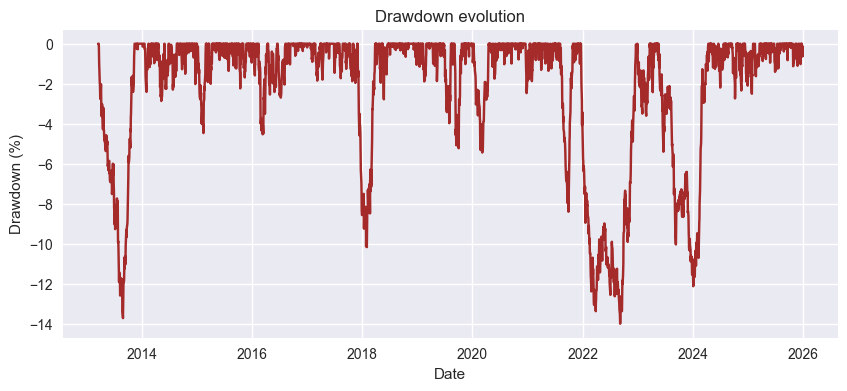

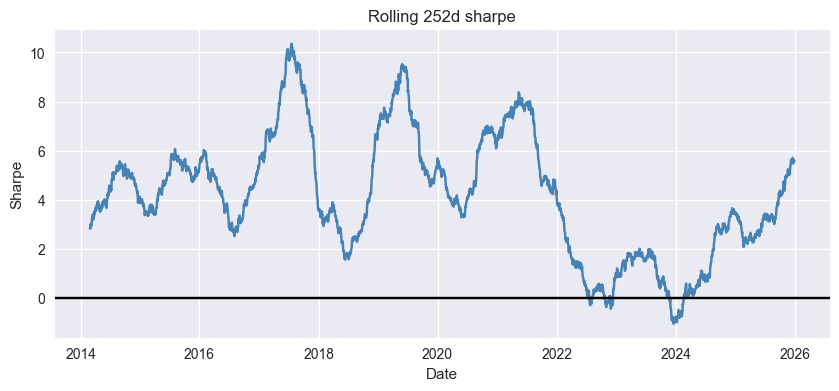

In [34]:
# TODO: create the three figures
plt.style.use('seaborn-v0_8')

plt.figure(figsize=(10, 4))
plt.plot(gross_equity_curve, color='forestgreen', label='Gross')
plt.plot(net_equity_curve, color='teal', label='Net')
plt.plot(targeted_equity_curve, color='mediumpurple', label='Targeted vol')
plt.grid(True)
plt.title('Equity curve comparison')
plt.xlabel('Date')
plt.ylabel('Equity')
plt.legend()
plt.show()

targeted_peak = targeted_equity_curve.cummax()
targeted_dd = (targeted_equity_curve - targeted_peak)/targeted_peak
plt.figure(figsize=(10, 4))
plt.plot(targeted_dd*100, color='brown')
plt.grid(True)
plt.title('Drawdown evolution')
plt.xlabel('Date')
plt.ylabel('Drawdown (%)')
plt.show()

targeted_sharpe = targeted_returns.rolling(252).mean() / targeted_returns.rolling(252).std() * np.sqrt(TRADING_DAYS)
plt.figure(figsize=(10, 4))
plt.plot(targeted_sharpe, color='steelblue')
plt.grid(True)
plt.title('Rolling 252d sharpe')
plt.xlabel('Date')
plt.ylabel('Sharpe')
plt.axhline(0, color='black')
plt.show()
